In [1]:
import numpy as np

In [2]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import _process_target_state_input
from quantum_functions import find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_iterative_n_wise

In [3]:
# 1. Define initial circuits for concatenation Dictionaries
state_probs_bell = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)} # 2-qubit state
circ_bell = create_initial_circuit2(state_probs_bell)

state_probs_ghz_ish = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)} # 2-qubit state
circ_ghz_ish = create_initial_circuit2(state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)}
state_probs_target2_amplitudes = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)}


In [4]:
# --- Demonstrate Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Brute-Force Search ---")
print("="*40)
# WARNING: max_cnot_depth grows exponentially! Keep it small (e.g., 1, 2, or 3)
max_brute_force_depth = 10 # Testing up to 2 CNOTs for demonstration

best_cnot_sequence_brute_force, min_kl_brute_force = find_best_cnot_sequence_brute_force(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_brute_force_depth,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_brute_force:
    print(f"Brute-Force Search Optimal CNOT sequence (Depth {max_brute_force_depth}) found:")
    for cnot in best_cnot_sequence_brute_force:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_brute_force:.6f}")

    # Construct and draw the final best circuit from brute-force search
    ng_circ1_for_brute_force = circ_bell.num_qubits
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, ng_circ1_for_brute_force, best_cnot_sequence_brute_force
    )
    print("\n--- Final Optimized Circuit (Brute-Force) ---")
    print(final_best_circuit_brute_force.draw('text'))
else:
    print("Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_brute_force:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_brute_force.draw('text'))
print("="*40 + "\n")


--- Running Brute-Force Search ---

--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 10) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.061938
Initial best KL sum: 40.061938 (from baseline)

 Number of possible single cnots 8

--- Testing combinations with 1 CNOTs ---
  --> New best sequence found: [(0, 2)] with KL Sum: 34.767674
  --> New best sequence found: [(2, 0)] with KL Sum: 34.427466
  --> New best sequence found: [(0, 3)] with KL Sum: 34.281547
  --> New best sequence found: [(3, 0)] with KL Sum: 33.944357

--- Testing combinations with 2 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 0)] with KL Sum: 28.925414
  --> New best sequence found: [(0, 2), (2, 1)] with KL Sum: 28.711728
  --> New best sequence found: [(2, 0), (0, 3)] with KL Sum: 28.394873
  --> New best sequence found: [(1, 2), (2, 0)] with KL Sum: 28.142130

--- Testing combinations with 3 CNOTs ---
  --> New best sequence f

KeyboardInterrupt: 


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'01': 1013, '10': 987}
Counts for c_measure2: {'00': 1024, '11': 976}


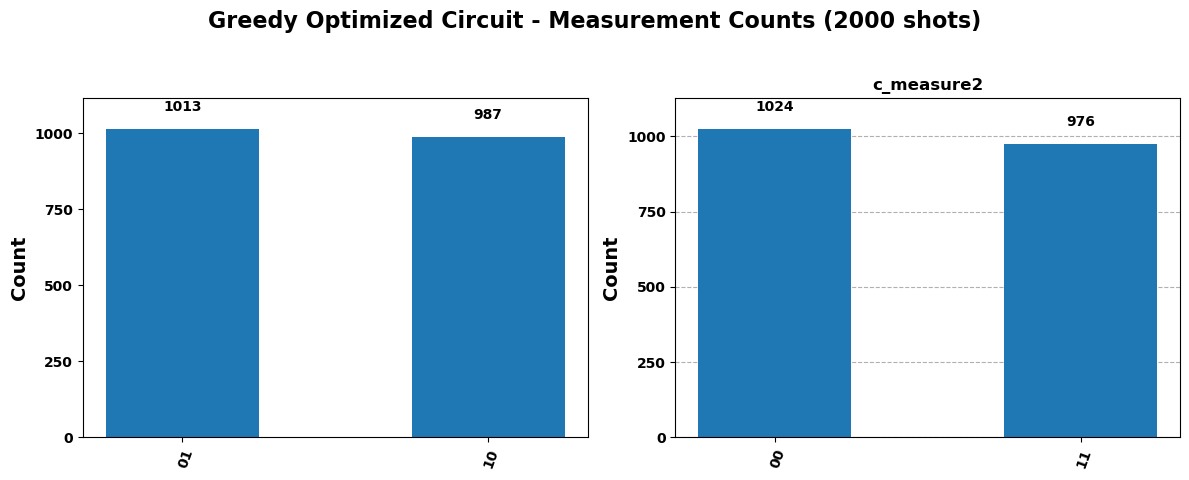

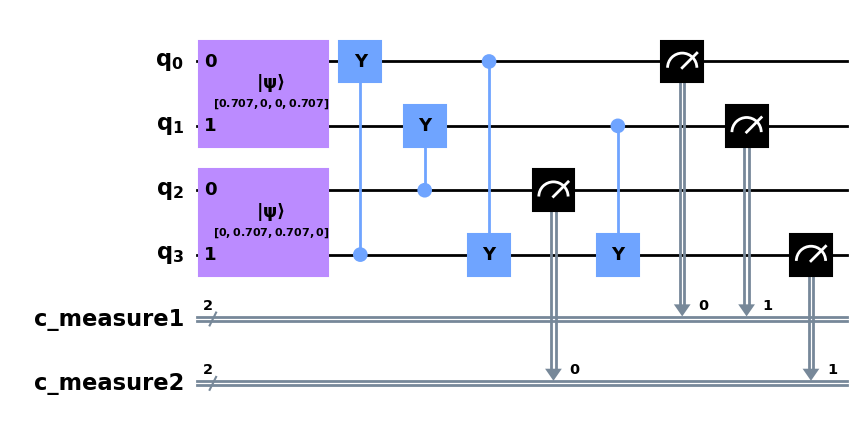

In [ ]:
plot_measurement_histograms(final_best_circuit_brute_force, nshots=2000, title_prefix="Greedy Optimized Circuit")
final_best_circuit_brute_force.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


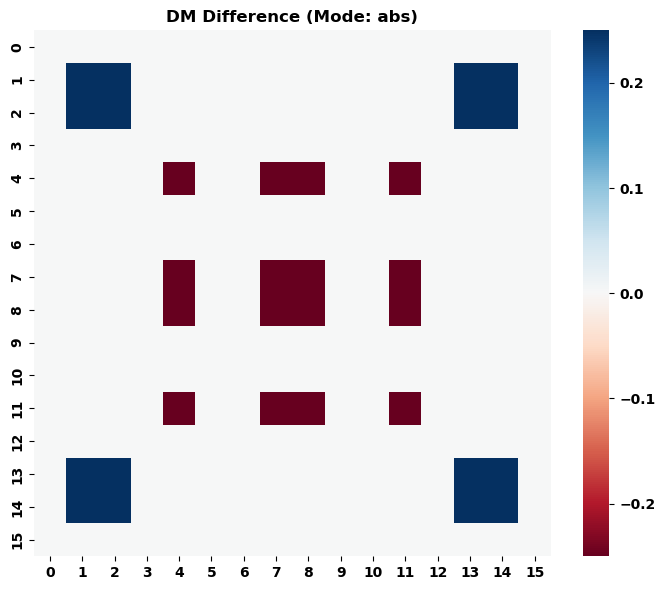


--- CNOT Analysis (abs) ---
Max Signal: 0.2500
Candidates Found: 12 / 12
------------------------------

Initial KL divergence (baseline): 40.060347

--- Starting Epoch 1/12 (Addition) with CNOT: (0, 1) (KL: 34.870144) ---
    --> Found a better KL on this path: 28.491724 at depth 2 with added CNOT (2, 0)
    --> Found a better KL on this path: 20.947529 at depth 3 with added CNOT (0, 3)
    --> Found a better KL on this path: 15.140811 at depth 4 with added CNOT (0, 2)
    --> Found a better KL on this path: 11.447679 at depth 5 with added CNOT (3, 1)
    --> Found a better KL on this path: 9.575887 at depth 6 with added CNOT (1, 3)
    --> Found a better KL on this path: 7.826489 at depth 7 with added CNOT (1, 2)
  Epoch 1 best KL Sum: 7.826489
  --> Epoch 1 found a new overall best KL Sum: 7.826489

--- Starting Epoch 2/12 (Addition) with CNOT: (0, 3) (KL: 34.410291) ---
    --> Found a better KL on this path: 28.735264 at depth 2 with added CNOT (3, 0)
    --> Found a better KL on

In [5]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 20
min_greedy_depth = 10

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ_bell,
    circ_ghz_ish,
    state_probs_bell,
    state_probs_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: Greedy Optimized Circuit ---
Counts for c_measure1: {'10': 1005, '01': 959, '00': 20, '11': 16}
Counts for c_measure2: {'11': 1832, '10': 132, '01': 20, '00': 16}


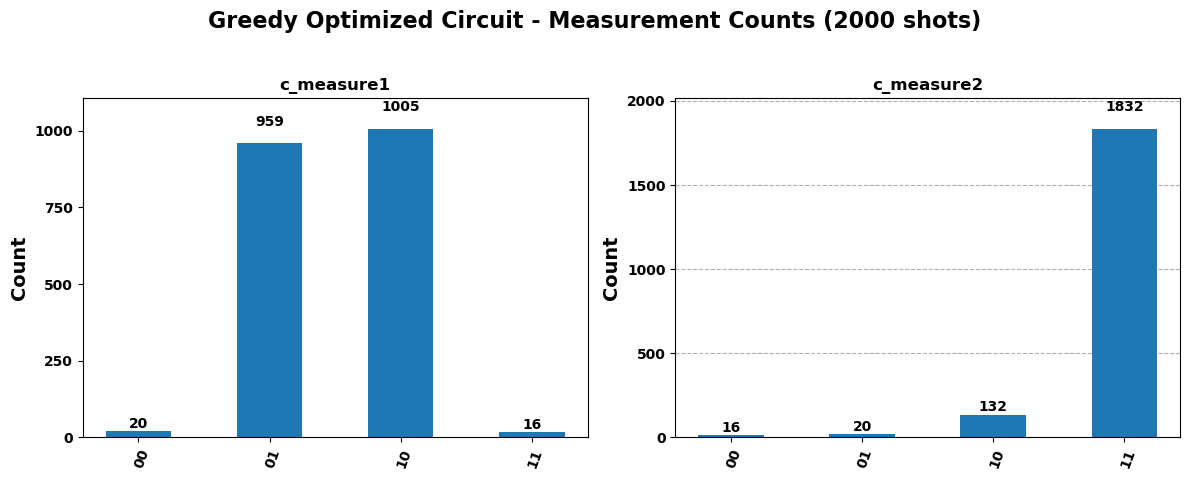

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


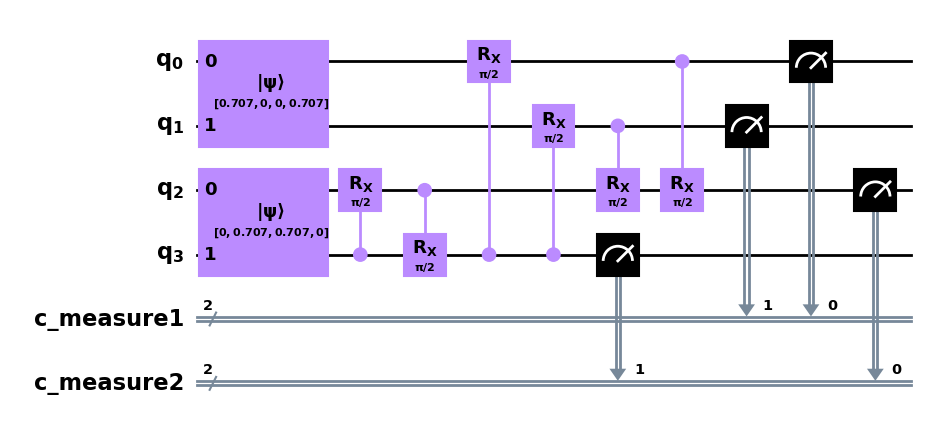

In [6]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Running CRX Angle Optimization (based on Multi-epoch CNOT topology) ---

--- Starting CRX Angle Optimization (6 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.3118', '1.9804', '1.9571', '1.2315', '1.1981', '1.2572']
CRX Angle Optimization took: 10.49 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.3118', '1.9804', '1.9571', '1.2315', '1.1981', '1.2572']
  Minimum Combined KL Divergence with Optimized CRX: 0.724154


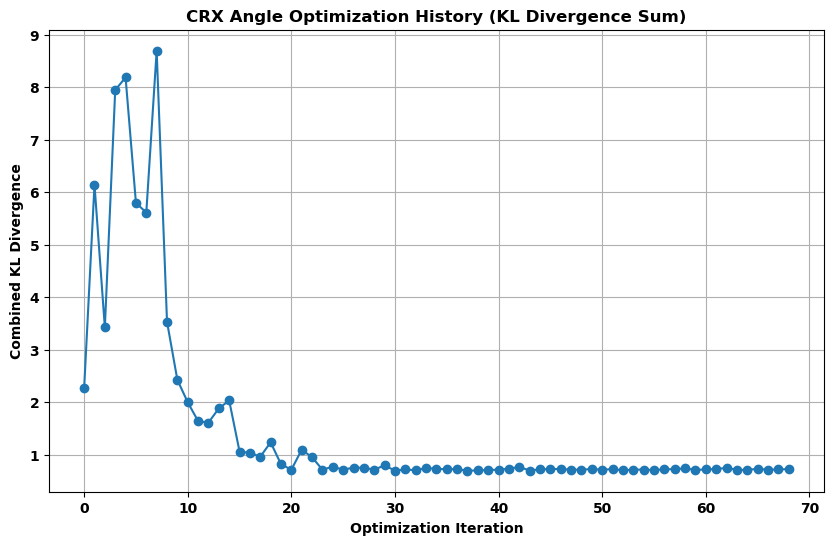


--- Final Optimized Circuit (CRX Angles) ---
              ┌──────────────────────────────────┐                            »
         q_0: ┤0                                 ├────────────────────────────»
              │  Initialize(0.70711,0,0,0.70711) │                            »
         q_1: ┤1                                 ├────────────────────────────»
              ├──────────────────────────────────┤┌────────────┐              »
         q_2: ┤0                                 ├┤ Rx(1.3118) ├──────■───────»
              │  Initialize(0,0.70711,0.70711,0) │└─────┬──────┘┌─────┴──────┐»
         q_3: ┤1                                 ├──────■───────┤ Rx(1.9804) ├»
              └──────────────────────────────────┘              └────────────┘»
c_measure1: 2/════════════════════════════════════════════════════════════════»
                                                                              »
c_measure2: 2/════════════════════════════════════════════════════════════

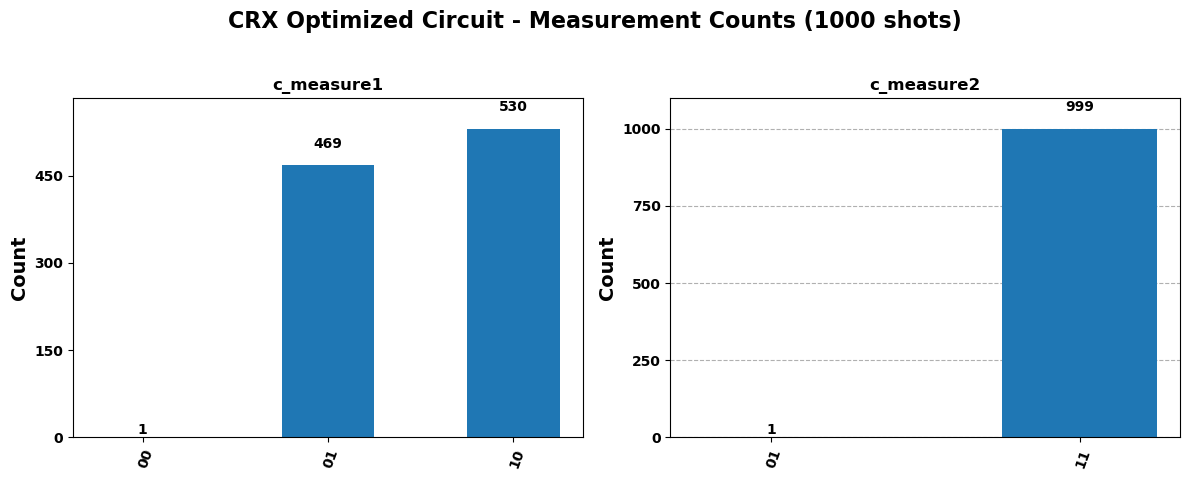

({'10': 530, '01': 469, '00': 1}, {'11': 999, '01': 1})

In [11]:
import matplotlib.pyplot as plt

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on Multi-epoch CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=2000,
    etol=1e-4,
    opt_method='COBYLA', # Using L-BFGS-B for angle optimization
    initial_angle_value=np.pi/2 # Start angles at pi (CNOT equivalent)
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish),
    circ_bell.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")


--- Running iterative pair-wise Search ---

--- Starting Iterative Pairwise Search ---


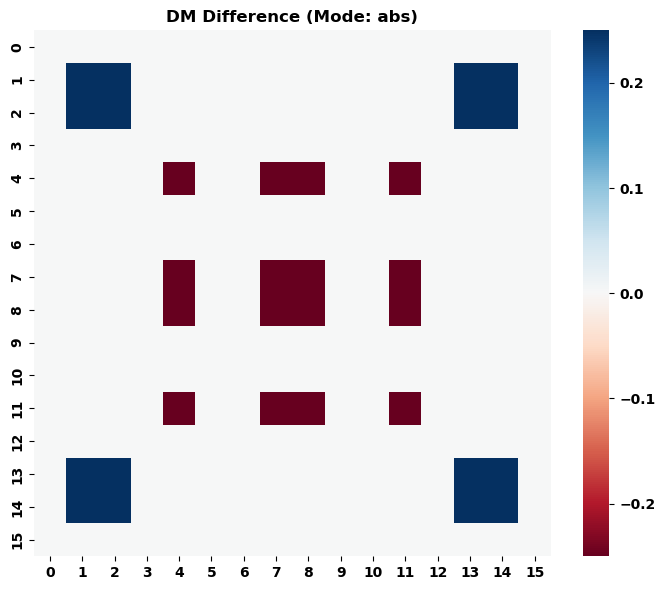


--- CNOT Analysis (abs) ---
Max Signal: 0.2500
Candidates Found: 12 / 12
------------------------------

Number of initial CNOT candidates: 12
Initial KL-divergence: 40.060632

  - Starting Efficiency-Optimized Search -

--- Iteration 1 | Current KL: 40.060263 ---
   - Single Insertion Phase: Added (1, 3) at index 0. New KL: 34.380977
  [Phase 1] Added Single: (1, 3) | New KL: 34.380977
  [Phase 2] Added Pair: ((2, 3), (3, 0)) | New KL: 21.345080

--- Iteration 2 | Current KL: 21.345080 ---
   - Single Insertion Phase: Added (3, 2) at index 1. New KL: 13.592183
  [Phase 1] Added Single: (3, 2) | New KL: 13.592183
  [Phase 2] Added Pair: ((1, 0), (2, 1)) | New KL: 6.985976
   - Deletion Phase: Best Removed (1, 0). New KL: 6.299083
  [Phase 3] Pruned: (1, 0) | New KL: 6.299083

--- Iteration 3 | Current KL: 6.299083 ---
  - No improvements in any phase. Search Terminated.

--- Total Search Time: 51.83s ---

--- Pairwise Addition Result ---
Best sequence after addition: [(1, 3), (3, 2), 

In [12]:
# This is a good set of functions!
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

# This is the call:
# --- Demonstrate Iterative Pairwise Search ---
print("\n" + "="*40)
print("--- Running iterative pair-wise Search ---")
print("="*40)

# Apply vector normalization to the new dictionaries
normalized_state_target1_amplitudes = vector_normalize_dictionary_values(state_probs_target1_amplitudes)
normalized_state_target2_amplitudes = vector_normalize_dictionary_values(state_probs_target2_amplitudes)
normalized_state_bell = vector_normalize_dictionary_values(state_probs_bell)
normalized_state_ghz_ish = vector_normalize_dictionary_values(state_probs_ghz_ish)


initial_cnot_config, best_add_sequence, best_add_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ_bell,
    circ_ghz_ish,
    normalized_state_bell, 
    normalized_state_ghz_ish,
    normalized_state_target1_amplitudes,
    normalized_state_target2_amplitudes,
    nshots=5000,
    threshold=0.05,
    nchoose=2
)

print("\n" + "="*40)
if best_add_sequence: # Use best_add_sequence as it's the result of the addition phase
    print("Iterative Search Optimal CNOT sequence found after addition phase:")
    for cnot in best_add_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {best_add_kl_sum:.6f}")

    # Construct and draw the final best circuit from the search
    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_add_sequence
    )
    print("\n--- Final Optimized Circuit (Iterative Pairwise Search) ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Iterative Pairwise Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {best_add_kl_sum:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")



--- Running circuit for: Greedy Optimized Circuit ---
Counts for c_measure1: {'01': 876, '10': 722, '11': 272, '00': 130}
Counts for c_measure2: {'10': 246, '11': 1457, '00': 259, '01': 38}


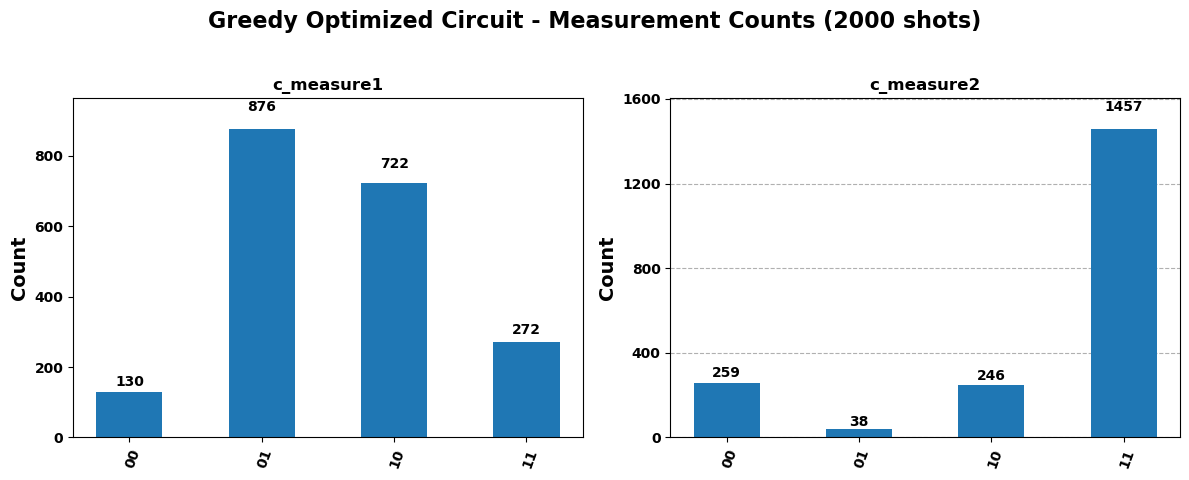

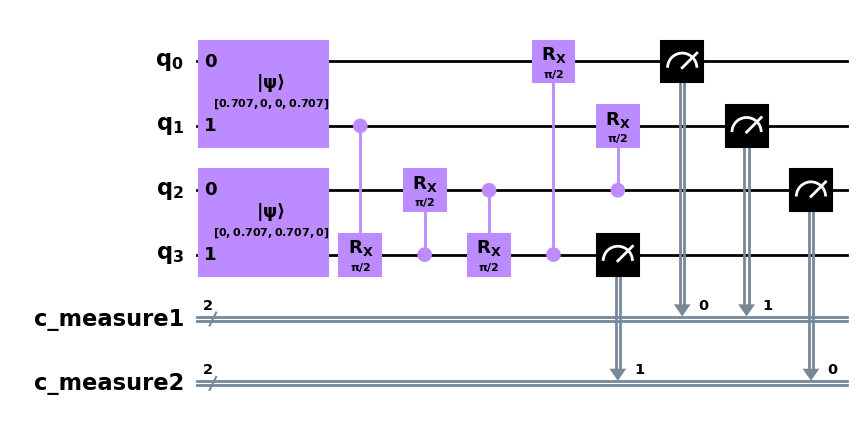

In [13]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)